In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore, linregress
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress
from matplotlib.colors import PowerNorm
import seaborn as sns
import statsmodels.formula.api as smf

from MyLovelyFunctions import *

In [2]:
import sys
sys.path.insert(1, '../ProcessEvents')
from config import CATCHMENTS

In [3]:
region_order = ["North Scotland","East Scotland","West Scotland","North West England","North East England",
                "Yorkshire and Humber","West Midlands","East Midlands","East of England","Wales",
                "South West England","South East England","London"]

## ------------------------------------------------------------ ###
### Get rainfall events
    And add extra variables
## ------------------------------------------------------------ ###

In [13]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments_added_soilvars.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['start_year']>1991].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
# print(len(rainfall_events_all_df))
# rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['length']>10].copy()
# print(len(rainfall_events_all_df))
len(np.unique(rainfall_events_all_df['catchment_num']))

rainfall_events_all_df['fu_at_peak_old_mm'] = rainfall_events_all_df['fu_at_peak_old']*1000
rainfall_events_all_df['fu_at_peak_new_mm'] = rainfall_events_all_df['fu_at_peak_new']*1000

rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 1.1, 3, float('inf')],labels=['D', 'C', 'B', 'A'], right=False, include_lowest=True)

In [ ]:
# rainfall_events_all_df.sort_values(by='length', ascending=False)[['ens', 'catchment_num', 'event_num', 'max_precip']][:20]

## ------------------------------------------------------------ ###
### Get spatial data and add regional geometries to rainfall data
## ------------------------------------------------------------ ###

In [14]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)
regions_df["region_geometry"] = regions_df.geometry

catchments_df = CATCHMENTS
catchments_df["catchment_geometry"] = catchments_df.geometry

# Event points
rainfall_events_all_df = gpd.GeoDataFrame(rainfall_events_all_df,
                        geometry=gpd.points_from_xy(rainfall_events_all_df["x_coord"], rainfall_events_all_df["y_coord"]), 
                                          crs=regions_df.crs)

# Remove old sjoin columns if this dataframe has been joined before
rainfall_events_all_df = rainfall_events_all_df.drop(
    columns=["index_right", "geo_region", "region_geometry", "HA_NAME", "catchment_geometry"], errors="ignore")

# Join regions
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, regions_df[["geo_region", "region_geometry", "geometry"]],
    how="left", predicate="within")

# Drop index_right before the next sjoin, or geopandas will error on the clash
rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

# Join catchments
rainfall_events_all_df = gpd.sjoin(rainfall_events_all_df, catchments_df[["HA_NAME", "catchment_geometry", "geometry"]],
    how="left", predicate="within")

rainfall_events_all_df = rainfall_events_all_df.drop(columns=["index_right"], errors="ignore")

In [ ]:
# import glob
# current_min = 10
# for file in glob.glob("/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/*"):
#     file = pd.read_csv(file)
#     if min(file['event_durations']) < current_min:
#         current_min = min(file['event_durations'])
#         print(current_min)
# len(glob.glob("/scratch/hydro4/users/la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/*"))

</div>

<div style="background-color: lightblue; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Strength of correlation between flood and rainfall, in each region

</div>

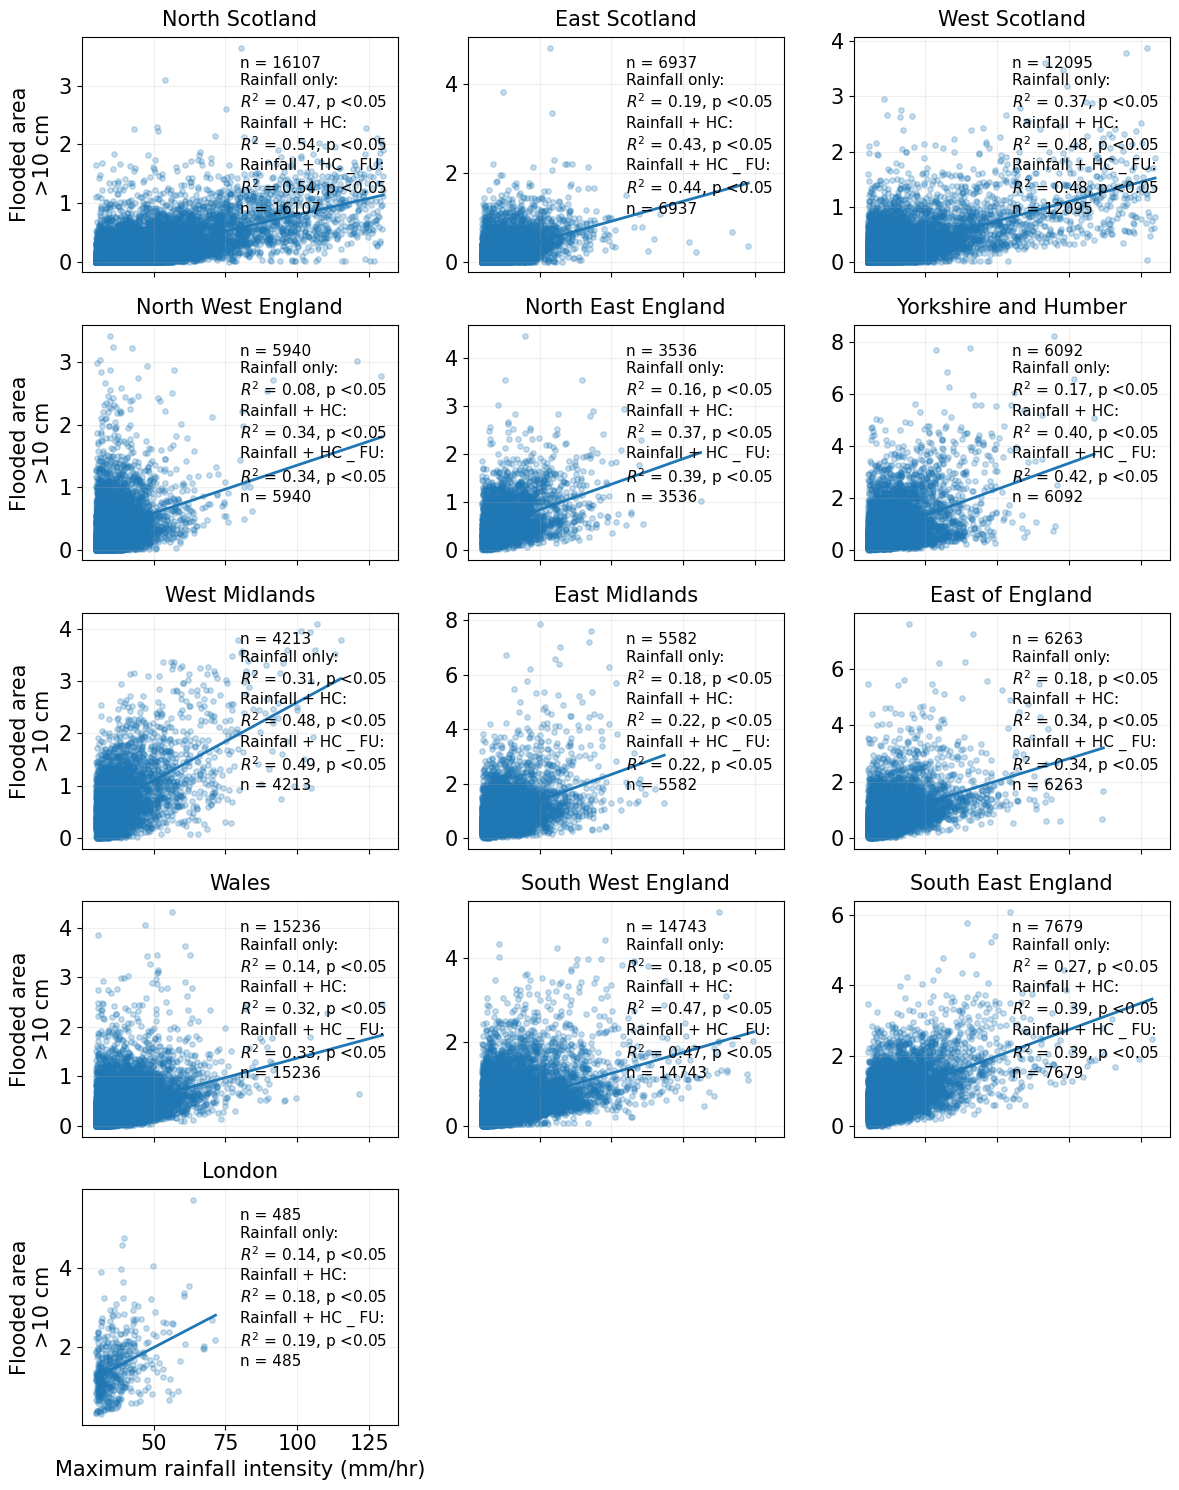

In [22]:
fig, axs = plt.subplots(5, 3, figsize=(12, 15), sharex=True, sharey=False)
axs = axs.flatten()

for i, hc in enumerate(region_order):

    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == hc].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])

    n_events = len(subset)

    x = subset["max_precip"]
    y = subset["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    # Multiple regression: flood area ~ rainfall intensity + HC
    model = smf.ols( "Q('10cm_area') ~ max_precip + fu_at_peak_old_mm",data=subset).fit()

    r2_multiple = model.rsquared
    p_hc = model.pvalues["fu_at_peak_old_mm"]
    if p_hc <0.005:
        p_hc = '<0.05'
    
    # Multiple regression: flood area ~ rainfall intensity + HC
    model3 = smf.ols( "Q('10cm_area') ~ max_precip + fumax_at_peak",data=subset).fit()

    r2_model3 = model3.rsquared
    p_model3 = model3.pvalues["fumax_at_peak"]
    if p_model3 <0.005:
        p_model3 = '<0.05'
        
    
    # Plot
    axs[i].scatter(x, y, alpha=0.25, s=15)
    axs[i].plot(x_line, y_line, linewidth=2)

    axs[i].set_title(hc, fontsize=15, pad=8)

    axs[i].text(
        0.5, 0.92,
        f"n = {n_events}\n"
        f"Rainfall only:\n"
        f"$R^2$ = {r2_simple:.2f}, p {p_value}\n"
        f"Rainfall + HC:\n"
        f"$R^2$ = {r2_multiple:.2f}, p {p_hc}\n"
        f"Rainfall + HC _ FU:\n"
        f"$R^2$ = {r2_model3:.2f}, p {p_model3}\n"
        f"n = {n_events}", transform=axs[i].transAxes, va="top", fontsize=11)

    axs[i].grid(alpha=0.2)
    axs[i].tick_params(axis="both", which="major", labelsize=15)

    if i % 3 == 0:
        axs[i].set_ylabel("Flooded area\n>10 cm", fontsize=15)
    else:
        axs[i].set_ylabel("")

    if i >= 12:
        axs[i].set_xlabel("Maximum rainfall intensity (mm/hr)", fontsize=15)
    else:
        axs[i].set_xlabel("")

for j in range(len(region_order), 5 * 3):
    axs[j].axis("off")

fig.tight_layout(h_pad=1.5, w_pad=1.2)
plt.show()

In [ ]:
for i, hc in enumerate(region_order):

    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == hc].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])

    n_events = len(subset)

    x = subset["max_precip"]
    y = subset["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    # Multiple regression: flood area ~ rainfall intensity + HC
    model = smf.ols( "Q('10cm_area') ~ max_precip + hc_at_peak",data=subset).fit()

    r2_multiple = model.rsquared
    p_hc = model.pvalues["hc_at_peak"]
    if p_hc <0.005:
        p_hc = '<0.05'
    
    # Multiple regression: flood area ~ rainfall intensity + HC
    model3 = smf.ols( "Q('10cm_area') ~ max_precip + hc_at_peak + fu_at_peak_mm",data=subset).fit()

    r2_model3 = model3.rsquared
    p_model3 = model3.pvalues["hc_at_peak"]
    if p_model3 <0.005:
        p_model3 = '<0.05'
    


In [26]:
def find_linear_relationship (variable1):
    x = subset[variable1]
    y = subset["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    print(" Simple:", f"{r2_simple:.2f}", p_value)  
    
def find_linear_relationship_with_max_precip (variable1, variable2=None):
    model = smf.ols( f"Q('10cm_area') ~ max_precip + {variable1}",data=subset).fit()
    if variable2!=None:
        model = smf.ols( f"Q('10cm_area') ~ max_precip  + {variable1} + {variable2}",data=subset).fit()

    r2 = model.rsquared
    p = model.pvalues[variable1]
    if p <0.005:
        p = '<0.05'
    else:
        p = f"= {round(p, 2)}"
        
    if variable2==None:        
        print(f" Only {variable1}:", f"{r2:.2f}, p", p)    
    else:
        print(f" {variable1} + {variable2} :", f"{r2:.2f}, p", p)    

In [30]:
subset = rainfall_events_all_df

for i, region in enumerate(np.unique(rainfall_events_all_df['catchment_num'])):
    print(region)
    subset = rainfall_events_all_df[
        rainfall_events_all_df["catchment_num"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])
    
    # Simple regression: flood area ~ rainfall intensity
    find_linear_relationship("max_precip")
    
#     # ------------------------
#     find_linear_relationship_with_max_precip("fu_at_peak_old_mm")    
    
#     # ------------------------    
#     find_linear_relationship_with_max_precip("hc_at_peak")    
    
#     # ------------------------    
#     find_linear_relationship_with_max_precip("fumax_at_peak") 
    
#     # ------------------------
#     find_linear_relationship_with_max_precip("hc_at_peak", "fu_at_peak_old_mm")

1
 Simple: 0.37 <0.05
10
 Simple: 0.42 <0.05
101
 Simple: 0.25 <0.05
102
 Simple: 0.31 <0.05
104
 Simple: 0.49 <0.05
105
 Simple: 0.55 <0.05
106
 Simple: 0.56 <0.05
107
 Simple: 0.34 <0.05
11
 Simple: 0.29 <0.05
12
 Simple: 0.25 <0.05
13
 Simple: 0.22 <0.05
14
 Simple: 0.20 <0.05
15
 Simple: 0.14 <0.05
16
 Simple: 0.07 <0.05
17
 Simple: 0.13 <0.05
18
 Simple: 0.09 <0.05
19
 Simple: 0.10 <0.05
2
 Simple: 0.72 <0.05
20
 Simple: 0.33 <0.05
21
 Simple: 0.27 <0.05
22
 Simple: 0.26 <0.05
23
 Simple: 0.13 <0.05
24
 Simple: 0.15 <0.05
25
 Simple: 0.18 <0.05
26
 Simple: 0.30 <0.05
27_a
 Simple: 0.10 <0.05
27_b
 Simple: 0.04 <0.05
27_c
 Simple: 0.16 <0.05
28_a
 Simple: 0.13 <0.05
28_b
 Simple: 0.22 <0.05
28_c
 Simple: 0.30 <0.05
29
 Simple: 0.25 <0.05
3
 Simple: 0.56 <0.05
30
 Simple: 0.26 <0.05
31
 Simple: 0.14 <0.05
32
 Simple: 0.21 <0.05
33_a
 Simple: 0.17 <0.05
33_b
 Simple: 0.19 <0.05
34
 Simple: 0.38 <0.05
35
 Simple: 0.31 <0.05
36
 Simple: 0.28 <0.05
37
 Simple: 0.15 <0.05
38
 Simple: 0.1

In [29]:
subset = rainfall_events_all_df

for i, region in enumerate(region_order):
    print(region)
    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak"])
    
    # Simple regression: flood area ~ rainfall intensity
    find_linear_relationship("max_precip")
    
    # ------------------------
    find_linear_relationship_with_max_precip("fu_at_peak_mm")    
    
    # ------------------------    
    find_linear_relationship_with_max_precip("hc_at_peak")    
    
    # ------------------------    
    find_linear_relationship_with_max_precip("fumax_at_peak") 
    
    # ------------------------
    find_linear_relationship_with_max_precip("hc_at_peak", "fu_at_peak_mm")

North Scotland
 Simple: 0.45 <0.05
 Only fu_at_peak_mm: 0.45, p =0.01
 Only hc_at_peak: 0.52, p <0.05
 Only fumax_at_peak: 0.53, p <0.05
 hc_at_peak + fu_at_peak_mm : 0.52, p <0.05
East Scotland
 Simple: 0.19 <0.05
 Only fu_at_peak_mm: 0.20, p <0.05
 Only hc_at_peak: 0.37, p <0.05
 Only fumax_at_peak: 0.44, p <0.05
 hc_at_peak + fu_at_peak_mm : 0.37, p <0.05
West Scotland
 Simple: 0.32 <0.05
 Only fu_at_peak_mm: 0.32, p <0.05
 Only hc_at_peak: 0.41, p <0.05
 Only fumax_at_peak: 0.46, p <0.05
 hc_at_peak + fu_at_peak_mm : 0.42, p <0.05
North West England
 Simple: 0.08 <0.05
 Only fu_at_peak_mm: 0.15, p <0.05
 Only hc_at_peak: 0.29, p <0.05
 Only fumax_at_peak: 0.34, p <0.05
 hc_at_peak + fu_at_peak_mm : 0.30, p <0.05
North East England
 Simple: 0.17 <0.05
 Only fu_at_peak_mm: 0.17, p <0.05
 Only hc_at_peak: 0.35, p <0.05
 Only fumax_at_peak: 0.40, p <0.05
 hc_at_peak + fu_at_peak_mm : 0.35, p <0.05
Yorkshire and Humber
 Simple: 0.14 <0.05
 Only fu_at_peak_mm: 0.15, p <0.05
 Only hc_at_p

In [11]:
from sklearn.ensemble import RandomForestRegressor

def rf_r2_and_importance(subset, features, target="10cm_area", random_state=42):
    """
    Fit a random forest for `target` ~ `features`, return OOB R² and
    each feature's importance.
    """
    X = subset[features]
    y = subset[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        oob_score=True,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X, y)

    r2 = rf.oob_score_
    importances = dict(zip(features, rf.feature_importances_))
    return r2, importances


for i, region in enumerate(region_order):
    print(region)
    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak", "fu_at_peak_mm"])

    # ------------------------
    # Simple: flood area ~ rainfall intensity only
    r2_simple, imp_simple = rf_r2_and_importance(subset, ["max_precip"])
    print(" Simple:", f"{r2_simple:.2f}", imp_simple)

    # ------------------------
    # + fu
    r2_fu, imp_fu = rf_r2_and_importance(subset, ["max_precip", "fu_at_peak_mm"])
    print(" Fu:", f"{r2_fu:.2f}", f"fu importance: {imp_fu['fu_at_peak_mm']:.2f}")

    # ------------------------
    # + hc
    r2_hc, imp_hc = rf_r2_and_importance(subset, ["max_precip", "hc_at_peak"])
    print(" HC:", f"{r2_hc:.2f}", f"hc importance: {imp_hc['hc_at_peak']:.2f}")

    # ------------------------
    # + fu + hc
    r2_fu_hc, imp_fu_hc = rf_r2_and_importance(subset, ["max_precip", "hc_at_peak", "fu_at_peak_mm"])
    print(" Fu and HC:", f"{r2_fu_hc:.2f}",
          f"fu importance: {imp_fu_hc['fu_at_peak_mm']:.2f}, hc importance: {imp_fu_hc['hc_at_peak']:.2f}")
    print('------------')

North Scotland
 Simple: 0.21 {'max_precip': np.float64(1.0)}
 Fu: 0.33 fu importance: 0.21
 HC: 0.65 hc importance: 0.36
 Fu and HC: 0.69 fu importance: 0.11, hc importance: 0.30
------------
East Scotland
 Simple: -0.19 {'max_precip': np.float64(1.0)}
 Fu: 0.14 fu importance: 0.44
 HC: 0.54 hc importance: 0.57
 Fu and HC: 0.54 fu importance: 0.16, hc importance: 0.50
------------
West Scotland
 Simple: -0.00 {'max_precip': np.float64(1.0)}
 Fu: 0.20 fu importance: 0.30
 HC: 0.57 hc importance: 0.44
 Fu and HC: 0.59 fu importance: 0.13, hc importance: 0.38
------------
North West England
 Simple: -0.33 {'max_precip': np.float64(1.0)}
 Fu: 0.01 fu importance: 0.49
 HC: 0.52 hc importance: 0.64
 Fu and HC: 0.53 fu importance: 0.18, hc importance: 0.56
------------
North East England
 Simple: -0.26 {'max_precip': np.float64(1.0)}
 Fu: 0.03 fu importance: 0.43
 HC: 0.64 hc importance: 0.61
 Fu and HC: 0.60 fu importance: 0.14, hc importance: 0.53
------------
Yorkshire and Humber
 Simple: 


KeyboardInterrupt



In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

def rf_oob_r2(subset, features, target="10cm_area", random_state=42):
    """Fit an RF and return OOB R² and feature importances."""
    X = subset[features]
    y = subset[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        oob_score=True,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X, y)
    return rf.oob_score_, dict(zip(features, rf.feature_importances_))


length_subset= rainfall_events_all_df[rainfall_events_all_df['length']<15]
all_results = []

for region in region_order:
    subset = length_subset[
        length_subset["geo_region"] == region].dropna(subset=["max_precip", "10cm_area", "hc_at_peak", "fu_at_peak_mm"])

    n = len(subset)

    model_specs = {
        "simple":     ["max_precip"],
        "fu":         ["max_precip", "fu_at_peak_mm"],
        "hc":         ["max_precip", "hc_at_peak"],
        "fu_and_hc":  ["max_precip", "hc_at_peak", "fu_at_peak_mm"],}

    r2s = {}
    importances = {}
    for name, feats in model_specs.items():
        r2, imp = rf_oob_r2(subset, feats)
        r2s[name] = r2
        importances[name] = imp

    all_results.append({
        "region": region,
        "n_events": n,
        "r2_simple": r2s["simple"],
        "r2_fu": r2s["fu"],
        "r2_hc": r2s["hc"],
        "r2_fu_and_hc": r2s["fu_and_hc"],
        "gain_fu": r2s["fu"] - r2s["simple"],
        "gain_hc": r2s["hc"] - r2s["simple"],
        "gain_fu_and_hc": r2s["fu_and_hc"] - r2s["simple"],
        "fu_importance_in_fu_model": importances["fu"]["fu_at_peak_mm"],
        "hc_importance_in_hc_model": importances["hc"]["hc_at_peak"],
        "fu_importance_in_combined": importances["fu_and_hc"]["fu_at_peak_mm"],
        "hc_importance_in_combined": importances["fu_and_hc"]["hc_at_peak"],})

    # Per-region printout, same shape as before
    print(region, f"(n={n})")
    print(" Simple:", f"{r2s['simple']:.2f}")
    print(" Fu:", f"{r2s['fu']:.2f}", f"(gain: {r2s['fu']-r2s['simple']:+.2f})")
    print(" HC:", f"{r2s['hc']:.2f}", f"(gain: {r2s['hc']-r2s['simple']:+.2f})")
    print(" Fu and HC:", f"{r2s['fu_and_hc']:.2f}", f"(gain: {r2s['fu_and_hc']-r2s['simple']:+.2f})")
    print('------------')

results_df = pd.DataFrame(all_results)
results_df

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

def rf_oob_r2(subset, features, target="10cm_area", random_state=42):
    """Fit an RF and return OOB R²."""
    X = subset[features]
    y = subset[target]
    rf = RandomForestRegressor(
        n_estimators=500,
        oob_score=True,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X, y)
    return rf.oob_score_


def rf_oob_r2_repeated(subset, features, target="10cm_area", n_seeds=5):
    """Average OOB R² over several random seeds, for a more stable estimate."""
    scores = [rf_oob_r2(subset, features, target, random_state=s) for s in range(n_seeds)]
    return np.mean(scores), np.std(scores)


all_results = []

for region in region_order:
    subset = length_subset[
        length_subset["geo_region"] == region
    ].dropna(subset=["max_precip", "10cm_area", "hc_at_peak", "fu_at_peak_mm", "fumax_at_peak"])

    n = len(subset)

    # ── Does FU add info beyond HC? ──────────────────────────────────
    r2_hc_only,    sd_hc_only    = rf_oob_r2_repeated(subset, ["max_precip", "hc_at_peak"])
    r2_hc_plus_fu, sd_hc_plus_fu = rf_oob_r2_repeated(subset, ["max_precip", "hc_at_peak", "fu_at_peak_mm"])
    gain_fu_over_hc = r2_hc_plus_fu - r2_hc_only

    # ── Does FU add info beyond fumax? ───────────────────────────────
    r2_fumax_only,    sd_fumax_only    = rf_oob_r2_repeated(subset, ["max_precip", "fumax_at_peak"])
    r2_fumax_plus_fu, sd_fumax_plus_fu = rf_oob_r2_repeated(subset, ["max_precip", "fumax_at_peak", "fu_at_peak_mm"])
    gain_fu_over_fumax = r2_fumax_plus_fu - r2_fumax_only

    all_results.append({
        "region": region,
        "n_events": n,
        "r2_hc_only": r2_hc_only,
        "r2_hc_plus_fu": r2_hc_plus_fu,
        "gain_fu_over_hc": gain_fu_over_hc,
        "r2_fumax_only": r2_fumax_only,
        "r2_fumax_plus_fu": r2_fumax_plus_fu,
        "gain_fu_over_fumax": gain_fu_over_fumax,
    })

    print(region, f"(n={n})")
    print(f"  HC alone:        {r2_hc_only:.3f} (±{sd_hc_only:.3f})")
    print(f"  HC + FU:         {r2_hc_plus_fu:.3f} (±{sd_hc_plus_fu:.3f})   gain: {gain_fu_over_hc:+.3f}")
    print(f"  fumax alone:     {r2_fumax_only:.3f} (±{sd_fumax_only:.3f})")
    print(f"  fumax + FU:      {r2_fumax_plus_fu:.3f} (±{sd_fumax_plus_fu:.3f})   gain: {gain_fu_over_fumax:+.3f}")
    print('------------')

results_df = pd.DataFrame(all_results)
results_df

In [ ]:
rainfall_events_all_df["fu_saturation_fraction"] = (
    rainfall_events_all_df["fu_at_peak_mm"] / rainfall_events_all_df["fumax_at_peak"]
)

In [ ]:
def commonality_analysis(subset, target="10cm_area",
                          static_var="hc_at_peak", dynamic_var="fu_at_peak_mm",
                          control="max_precip"):
    full    = smf.ols(f"Q('{target}') ~ {control} + {static_var} + {dynamic_var}", data=subset).fit().rsquared
    no_stat = smf.ols(f"Q('{target}') ~ {control} + {dynamic_var}", data=subset).fit().rsquared
    no_dyn  = smf.ols(f"Q('{target}') ~ {control} + {static_var}", data=subset).fit().rsquared
    base    = smf.ols(f"Q('{target}') ~ {control}", data=subset).fit().rsquared

    unique_static  = full - no_stat
    unique_dynamic = full - no_dyn
    shared = (full - base) - unique_static - unique_dynamic

    return {"unique_static": unique_static, "unique_dynamic": unique_dynamic,
            "shared": shared, "total_explained_beyond_precip": full - base}

for region in region_order:
    subset = rainfall_events_all_df[
        rainfall_events_all_df["geo_region"] == region
    ].dropna(subset=["max_precip", "10cm_area", "hc_at_peak", "fu_saturation_fraction"])
    result = commonality_analysis(subset)
    print(region, {k: round(v, 3) for k, v in result.items()})

In [ ]:
subset[["hc_at_peak", "fumax_at_peak", "fu_at_peak_mm"]].corr()

In [ ]:
rainfall_events_all_df[["hc_at_peak", "fumax_at_peak", "fu_at_peak_mm", "fu_saturation_fraction"]].corr()

In [ ]:
subset["hc_bin"] = pd.qcut(subset["hc_at_peak"], q=3, labels=["low_hc", "mid_hc", "high_hc"])

for hc_bin, group in subset.groupby("hc_bin", observed=True):
    if len(group) < 20:   # skip if too few events to trust
        continue
    slope, intercept, r_value, p_value, _ = linregress(group["fu_at_peak_mm"], group["10cm_area"])
    print(hc_bin, f"n={len(group)}", f"r²={r_value**2:.2f}", f"p={p_value:.3f}")